#**Order-Agnostic Autoregressive Model (OA-ARDM) Implementation**
**Probabilistic and Generative Machine Learning 2026** - Project 1
> Ana Pascual (100561873) & Cristina Sobrino (100471865)

This notebook implements the **Order-Agnostic Autoregressive Diffusion Model (OA-ARDM)**
introduced by Hoogeboom et al. (2022).

> Paper: [Autoregressive Diffusion Models — ICLR 2022](https://openreview.net/forum?id=Lm8T39vLDTE)

The core idea is that instead of generating data in a fixed left-to-right order,
ARDM trains a model to predict any token given any subset of the others, so
the generation order is randomised at every training step.
This makes ARDM useful for imputation: filling in missing entries
in partially observed data, with no architectural changes at inference time.

We chose a Transformer as our main backbone because its attention mechanism
has no assumption about the structure of the input, it treats every position
equally, which means the same architecture applies to both image pixels and
tabular features without modification.

**Experiments:**
1. **Binarized MNIST:** we train an OA-ARDM with a small Transformer and validate
   it on imputation (reconstructing images from a subset of visible pixels)
2. **Architecture comparison:** we train a small CNN under the same ARDM objective
   on MNIST and compare it against the Transformer
3. **Tabular data (UCI Mushroom):** we apply the Transformer-based ARDM to a
   categorical tabular dataset


**Notebook structure:**
1. Data — Binarized MNIST
2. Model — Bidirectional Transformer
3. Training — The ARDM objective
4. Results — Training curves and unconditional generation
5. Validation — Imputation from partial observations
6. Architecture comparison — Small CNN on MNIST
7. Tabular data — ARDM on UCI Mushroom

# **0. Imports and Settings**

In [1]:
import random
import numpy as np
import math

import torch
from torch import nn, Tensor
import torch.optim as optim
import torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer

from torch.nn.modules.activation import MultiheadAttention
from torch.nn.modules.normalization import LayerNorm
from torch.nn.modules.dropout import Dropout
from torch.nn.modules.linear import Linear
from torch.nn.modules.module import Module

import torchvision
from torchvision import transforms, datasets
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from typing import Optional, Any, Union, Callable
from functools import partial

import os
import re

In [2]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Then save to:
SAVE_PATH = "/content/drive/MyDrive/PGML/ARDM"

Mounted at /content/drive


# **1. Data - Binarized MNIST**

MNIST consists of 28×28 grayscale images of handwritten digits. We binarize each
pixel by thresholding at 0.5, so every pixel becomes either 0 (black) or 1 (white).
This gives us sequences of 784 binary tokens, which simplifies the output
distribution to a Bernoulli and the model only needs to output one logit per position.

We use three token values throughout the notebook:
- `0` — pixel off
- `1` — pixel on
- `2` — MASK (position not yet revealed to the model)

In [4]:
# Define custom transform for binarization
class Binarize(object):
    def __init__(self, threshold=0.5):
        self.threshold = threshold
    def __call__(self, tensor):
        return (tensor > self.threshold).float()

# Compose transforms
transform = transforms.Compose([
    transforms.ToTensor(), # converts PIL image to [0,1] float tensor
    Binarize(threshold=0.5) # float to {0,1} tokens
])

# Load MNIST dataset with binarization applied
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

#  Train - val - test split
full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

train_size = 50000
val_size   = 10000
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

#  DataLoaders
trainset = DataLoader(train_dataset, batch_size=512,  shuffle=True)
valset   = DataLoader(val_dataset,   batch_size=512, shuffle=False)
testset  = DataLoader(test_dataset,  batch_size=512, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.03MB/s]


Train samples: 50000
Val samples:   10000
Test samples:  10000


In [5]:
# Check one batch
for images, labels in trainset:
    print("Batch image shape:", images.shape)
    print("Batch labels shape:", labels.shape)
    print("Unique pixel values in a sample image:", torch.unique(images[0]))
    break

Batch image shape: torch.Size([512, 1, 28, 28])
Batch labels shape: torch.Size([512])
Unique pixel values in a sample image: tensor([0., 1.])


Visualization

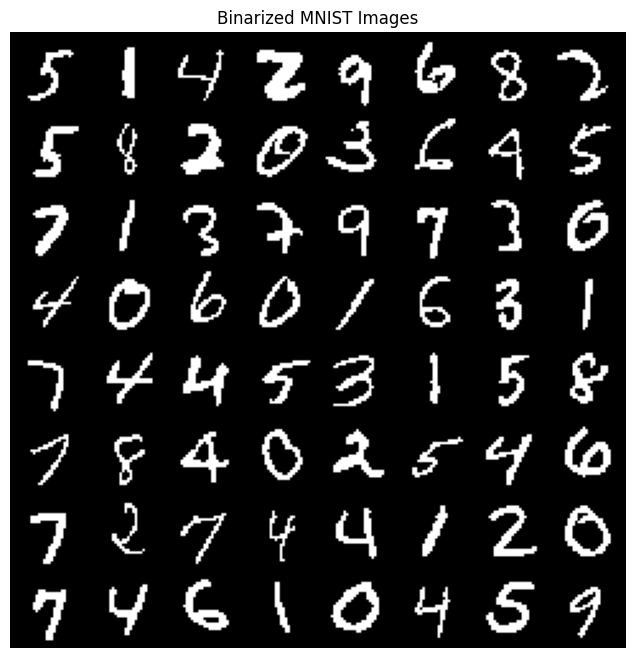

In [6]:
# Get batch of images from the DataLoader
data_iter = iter(trainset)
images, labels = next(data_iter)

# Create a grid of images (8x8 by default)
grid_img = make_grid(images[:64], nrow=8, padding=2)

# Plot the grid
plt.figure(figsize=(8, 8))
plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
plt.title("Binarized MNIST Images")
plt.axis('off')
plt.show()

# **2. Model - Bidirectional Transformer**

We use a small bidirectional Transformer encoder as the backbone. The bidirectionality is essential for ARDM. As the generation order is defined by the random permutation sampled at each training step rather than by the architecture, the model needs to attend to all visible tokens simultaneously when predicting a missing one.

This different to standard autoregressive models like GPT, where the causal mask enforces a fixed left-to-right ordering.

We kept the model deliberately small (~2M parameters), as the goal is to study the behaviour of the ARDM objective rather than achieving high-quality generation.

The implementation builds on Andrej Karpathy's
[minGPT](https://github.com/karpathy/minGPT) for the attention blocks, wrapped
following [Buomsoo Kim's Transformer tutorial](https://buomsoo-kim.github.io/attention/2020/04/21/Attention-mechanism-19.md/).
We made three modifications to adapt it to ARDM:
- the causal mask is removed
- dropout is set to zero
- the output head is changed from a vocabulary softmax to a single logit per position for binary prediction.

**Architecture:**
- Token embedding: vocab size 3 (`0`, `1`, `MASK`) → d = 128
- Sinusoidal positional encoding over 784 positions
- 4 Transformer encoder layers, 4 attention heads, FFN size 256
- Linear output head → 1 logit per position

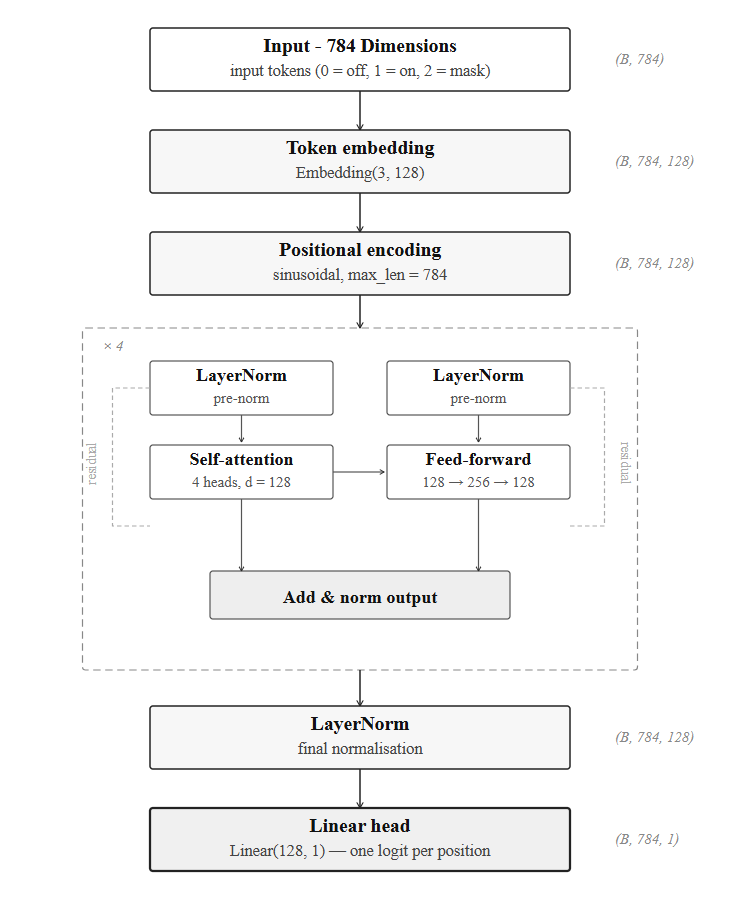

In [7]:
from IPython.display import Image
Image(f"{SAVE_PATH}/transformer_architecture.png", width=450)

In [8]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(d_model // 2) * (-math.log(10000.0) / (d_model // 2)))
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, :d_model // 2] = torch.sin(position * div_term)
        pe[0, :, d_model // 2:] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x: Tensor) -> Tensor:
        # x: (batch_size, seq_len, d_model)
        # slice to x.size(1) because seq_len may be shorter than max_len.
        x = x + self.pe[:, :x.size(1), :]
        return x


class SelfAttention(nn.Module):
    """
    Adapted from Karpathy's minGPT (github.com/karpathy/minGPT).
    A vanilla multi-head self-attention layer with a projection at the end.
    """

    def __init__(self, nembed, nhead, dropout):
        super().__init__()
        # key, query, value projections for all heads
        self.key = nn.Linear(nembed, nembed, bias=False)
        self.query = nn.Linear(nembed, nembed, bias=False)
        self.value = nn.Linear(nembed, nembed, bias=False)
        # regularization
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        # output projection
        self.proj = nn.Linear(nembed, nembed, bias=False)

        self.n_head = nhead

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        k = self.key(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = self.query(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = self.value(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))

        # no causal mask - every token attends to every other token
        att = F.softmax(att, dim=-1)

        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side

        # output projection
        y = self.proj(y)
        return y

class Block(nn.Module):
    """
    Adapted from Karpathy's minGPT (github.com/karpathy/minGPT).
    One Transformer encoder block: self-attention + MLP, both with residual connections.
    """

    def __init__(self, nembed, nhead, hidden_size):
        super().__init__()
        self.ln1 = nn.LayerNorm(nembed, eps=1e-6)
        self.ln2 = nn.LayerNorm(nembed, eps=1e-6)
        self.attn = SelfAttention(nembed=nembed, nhead=nhead, dropout=0.0)
        self.mlp = nn.Sequential(
            nn.Linear(nembed, hidden_size),
            nn.GELU(),  # smoother than ReLU, standard in modern Transformers
            nn.Linear(hidden_size, nembed),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class TransformerNet(nn.Module):
    """
    Wrapper adapted from Buomsoo Kim's Transformer tutorial series
    (buomsoo-kim.github.io/attention/2020/04/21/Attention-mechanism-19.md).
    Modified for ARDM: single-channel binary output, no causal mask, dropout = 0.
    """
    def __init__(self, num_src_vocab, num_tgt_vocab, embedding_dim, hidden_size, nheads, n_layers, max_src_len, max_tgt_len, dropout):
        super(TransformerNet, self).__init__()
        # embedding layers
        # Embedding maps each token id (0, 1, 2) to a dense vector.
        # The MASK token (2) gets its own learned embedding, which tells the model "this position exists but its value is unknown".

        self.embedding = nn.Embedding(num_src_vocab, embedding_dim)

        # positional encoding layers
        self.pe = PositionalEncoding(embedding_dim, dropout = 0.0, max_len = max_src_len)

        # encoder/decoder layers
        self.decoder = nn.Sequential(*[Block(nembed=embedding_dim, nhead=nheads, hidden_size=hidden_size) for _ in range(n_layers)])
        self.ln_f = LayerNorm(embedding_dim, eps=1e-6)

        # final dense layer
        self.dense = nn.Linear(embedding_dim, num_tgt_vocab)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Embedding):
            #print("Embedding", module)
            torch.nn.init.normal_(module.weight, mean=0.0, std=1.0)
        elif isinstance(module, nn.Linear):
            #print("Linear", module)
            torch.nn.init.xavier_uniform_(module.weight)
            if isinstance(module, nn.Linear) and module.bias is not None:
                #print("Linear bias", module)
                torch.nn.init.normal_(module.bias, mean=0.0, std=1e-6)
        elif isinstance(module, nn.LayerNorm):
            #print("LayerNorm", module)
            torch.nn.init.zeros_(module.bias)
            torch.nn.init.ones_(module.weight)

    def forward(self, x):
        x = x.long()
        y = self.embedding(x)
        y = self.pe(y)

        y = self.decoder(y)
        y = self.ln_f(y)
        logits = self.dense(y)
        return logits

Model

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
model = TransformerNet(
    num_src_vocab=3,
    num_tgt_vocab=1,
    embedding_dim=128,
    hidden_size=256,
    nheads=4,
    n_layers=4,
    max_src_len=784,
    max_tgt_len=784,
    dropout=0.0
).to(device)


# **3. Training - ARDM objective**

The ARDM training objective (Equation 5 in the paper) is:

$$\mathcal{L} = \mathbb{E}_{\sigma, t} \left[ -\log p_\theta(x_{\sigma(t)} \mid \mathbf{x}_{\sigma(<t)}) \right]$$

At each training step, the model is asked to predict one missing token given all
the tokens that come before it in a randomly sampled ordering. Concretely:

1. Sample a random permutation $\sigma$ over all 784 positions
2. Sample a random step $t \in \{0, \dots, 783\}$
3. Mask all tokens at positions $\sigma(t), \sigma(t+1), \dots, \sigma(783)$ - these become `MASK`
4. The target is the token at position $\sigma(t)$ — the first masked position
5. Compute BCE loss only at that position

By randomising both the ordering and the step, the model learns to predict any
token given any subset of the others, which is what we need for
order-agnostic generation and imputation.

A useful sanity check: a random Bernoulli predictor (always guessing 0.5)
achieves a loss of $\ln(2) \approx 0.693$. The model should drop below this
immediately and keep improving from there.

We initially trained for 10 epochs as a sanity check. The loss curves showed
three things: the model was clearly learning (loss well below the random baseline of 0.693), the batch-level variance was high but expected given that we compute loss at a single randomly chosen position per sample, and there were no signs of
overfitting. This suggested the model had room to improve with more training, so
we extended to 50 epochs with cosine annealing to bring the learning rate down gradually and help convergence.

In [ ]:
# Optimiser & scheduler
MASK = 2
epochs = 50
warmup = 10   # flat lr for first 10 epochs, then cosine decay

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = epochs - warmup,  # decay over the remaining 40 epochs
    eta_min = 1e-5              # floor lr
)

os.makedirs(SAVE_PATH, exist_ok=True)


# Training loop
batch_losses = []
epoch_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for i, (images, _) in enumerate(trainset):
        B = images.shape[0]
        x = images.view(B, 784).long().to(device)  # flatten to sequence

        # Step 1-2: sample a random permutation and a random step t
        sigma = torch.argsort(torch.rand(B, 784), dim=1).to(device)  # (B, 784)
        t     = torch.randint(0, 784, (B,)).to(device)               # (B,)

        # Step 3: mask all positions at rank >= t in the permutation
        # rank_mask[b, i] = True if position i should be masked for sample b
        masked_x   = x.clone()
        t_expanded = t.unsqueeze(1)                               # (B, 1)
        positions  = torch.arange(784, device=device).unsqueeze(0)  # (1, 784)
        rank_mask  = positions >= t_expanded                      # (B, 784)

        # scatter_mask maps from permutation order back to pixel positions
        scatter_mask = torch.zeros(B, 784, dtype=torch.bool, device=device)
        scatter_mask.scatter_(1, sigma, rank_mask)
        masked_x[scatter_mask] = MASK

        # Step 4: target is the token at the first masked position σ(t)
        target_pos = sigma[torch.arange(B, device=device), t]
        target_val = x[torch.arange(B, device=device), target_pos].float()

        # Step 5: forward pass and BCE loss at the target position only
        logits = model(masked_x).squeeze(-1)                          # (B, 784)
        pred   = logits[torch.arange(B, device=device), target_pos]  # (B,)
        loss   = F.binary_cross_entropy_with_logits(pred, target_val)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()

        batch_losses.append(loss.item())
        total_loss += loss.item()

    epoch_avg = total_loss / len(trainset)
    epoch_losses.append(epoch_avg)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{epochs} — Loss: {epoch_avg:.4f}, LR: {current_lr:.6f}")

    # Save a checkpoint every epoch so we can resume or replot later
    torch.save(model.state_dict(), f"{SAVE_PATH}/ardm_epoch{epoch+1:02d}.pt")

    # Start cosine decay after warmup
    if epoch + 1 >= warmup:
        scheduler.step()

The model was trained previously and checkpoints were saved at each epoch.
In the next section we reconstruct the learning curve by evaluating each
checkpoint on a random subset of the training and validation sets for speed.
The loss estimates are slightly noisier than a full evaluation, but the trend
across epochs is still visible.

In [ ]:
N_EVAL_BATCHES = 50  # use a subset for speed
WEIGHTS_PATH = f"{SAVE_PATH}/weights"
MASK = 2

ckpt_files = sorted(
    [f for f in os.listdir(WEIGHTS_PATH) if re.match(r"ardm_epoch\d+\.pt", f)],
    key=lambda x: int(re.search(r"\d+", x).group())
)

train_losses = []
val_losses   = []

def evaluate_subset(loader, model, n_batches):
    total_loss, total_batches = 0.0, 0
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= n_batches:
                break
            images = batch[0] if isinstance(batch, (list, tuple)) else batch
            B = images.shape[0]
            x = images.view(B, 784).long().to(device)

            sigma        = torch.argsort(torch.rand(B, 784, device=device), dim=1)
            t            = torch.randint(0, 784, (B,), device=device)
            masked_x     = x.clone()
            t_expanded   = t.unsqueeze(1)
            positions    = torch.arange(784, device=device).unsqueeze(0)
            rank_mask    = positions >= t_expanded
            scatter_mask = torch.zeros(B, 784, dtype=torch.bool, device=device)
            scatter_mask.scatter_(1, sigma, rank_mask)
            masked_x[scatter_mask] = MASK

            target_pos = sigma[torch.arange(B, device=device), t]
            target_val = x[torch.arange(B, device=device), target_pos].float()

            logits = model(masked_x).squeeze(-1)
            pred   = logits[torch.arange(B, device=device), target_pos]
            loss   = F.binary_cross_entropy_with_logits(pred, target_val)

            total_loss    += loss.item()
            total_batches += 1

    return total_loss / total_batches

for fname in ckpt_files:
    path = os.path.join(WEIGHTS_PATH, fname)
    checkpoint = torch.load(path, map_location=device)

    # Handle both saving formats
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model.eval()

    train_loss = evaluate_subset(trainset, model, N_EVAL_BATCHES)
    val_loss   = evaluate_subset(testset,  model, N_EVAL_BATCHES)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    epoch_num = int(re.search(r"\d+", fname).group())
    print(f"Epoch {epoch_num:02d} — train: {train_loss:.4f}, val: {val_loss:.4f}")

Epoch 01 — train: 0.2635, val: 0.2536
Epoch 02 — train: 0.2492, val: 0.2496
Epoch 03 — train: 0.1846, val: 0.1856
Epoch 04 — train: 0.1743, val: 0.1876
Epoch 05 — train: 0.1586, val: 0.1629
Epoch 06 — train: 0.1618, val: 0.1695
Epoch 07 — train: 0.1904, val: 0.1698
Epoch 08 — train: 0.1519, val: 0.1374
Epoch 09 — train: 0.1525, val: 0.1467
Epoch 10 — train: 0.1328, val: 0.1284
Epoch 11 — train: 0.1332, val: 0.1505
Epoch 12 — train: 0.1460, val: 0.1291
Epoch 13 — train: 0.1427, val: 0.1314
Epoch 14 — train: 0.1620, val: 0.1323
Epoch 15 — train: 0.1332, val: 0.1435
Epoch 16 — train: 0.1364, val: 0.1322
Epoch 17 — train: 0.1347, val: 0.1379
Epoch 18 — train: 0.1220, val: 0.1188
Epoch 19 — train: 0.1440, val: 0.1313
Epoch 20 — train: 0.1157, val: 0.1348
Epoch 21 — train: 0.1286, val: 0.1347
Epoch 22 — train: 0.1102, val: 0.1305
Epoch 23 — train: 0.1263, val: 0.1280
Epoch 24 — train: 0.1203, val: 0.0994
Epoch 25 — train: 0.1145, val: 0.1184
Epoch 26 — train: 0.1061, val: 0.1151
Epoch 27 — t

# **4. Results -  Training curves and unconditional generation**

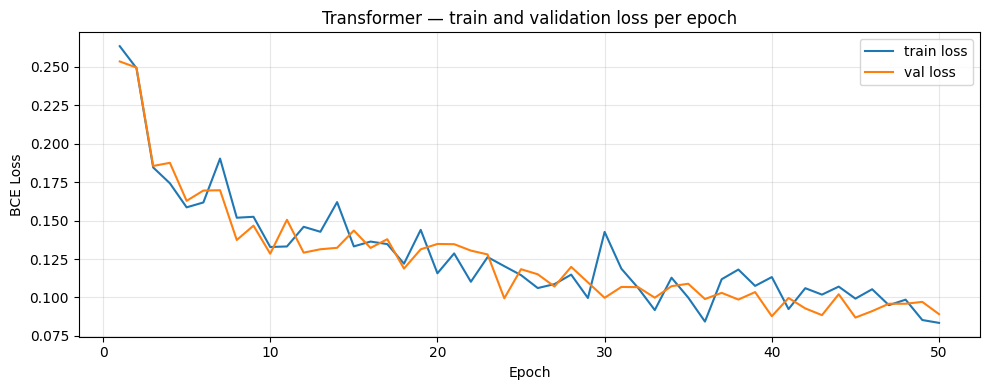


Best model: epoch 45 — val loss: 0.0869


In [ ]:
# Plot
epochs_x = [int(re.search(r"\d+", f).group()) for f in ckpt_files]

plt.figure(figsize=(10, 4))
plt.plot(epochs_x, train_losses, label='train loss')
plt.plot(epochs_x, val_losses,   label='val loss')
plt.title("Transformer — train and validation loss per epoch")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_epoch = epochs_x[val_losses.index(min(val_losses))]
print(f"\nBest model: epoch {best_epoch} — val loss: {min(val_losses):.4f}")

Both curves decrease steadily from around 0.26 down to roughly 0.09 by
epoch 50, well below the random baseline of ln(2) ≈ 0.693. The train and
validation curves track each other very closely throughout, which tells us
the model is generalising well and not overfitting. The noise in the curves
is expected given that the ARDM objective evaluates at a single randomly
chosen position per sample at each step.

We selected the checkpoint at epoch 45, which achieved the best validation
loss of 0.087. Since we used the test set to monitor training rather than
a separate validation set, it is not fully held out. Given the size of
MNIST however, this is unlikely to have a significant impact on the results.

### Unconditional Generation

To generate a sample we start from a fully masked sequence and fill in
one token at a time following a random order. At each step the model sees
all previously generated tokens and predicts the next one:

```
1. Start with a fully masked sequence [MASK, MASK, ..., MASK]
2. Sample a random order σ over all 784 positions
3. For t = 0, 1, ..., 783:
    - Feed the current sequence to the model
    - Get the logit at position σ(t)
    - Sample 0 or 1 from Bernoulli(sigmoid(logit))
    - Fill that position and move on
````

This is sequential sampling which samples one token per forward pass and 784 passes per
image. It is the correct way to sample from ARDM since each token is fully
conditioned on all previously generated ones.

We also try parallel block
sampling, where we fill K tokens per forward pass instead of one. This is
an approximation but much faster, and it lets us see how much quality we
lose by cutting the number of forward passes.

In [26]:
# Load best model checkpoint
WEIGHTS_PATH = f"{SAVE_PATH}/weights"
best_ckpt = torch.load(f"{WEIGHTS_PATH}/ardm_epoch45.pt", map_location=device)

if isinstance(best_ckpt, dict) and 'model_state_dict' in best_ckpt:
    model.load_state_dict(best_ckpt['model_state_dict'])
else:
    model.load_state_dict(best_ckpt)

model.eval()
print("Loaded best model — epoch 45, val loss: 0.0869")

Loaded best model — epoch 45, val loss: 0.0869


In [27]:
MASK = 2

@torch.no_grad()
def sample_sequential(model, n_samples=16, device=device):
    """
    Sequential sampling: one token per forward pass, 784 passes per image.
    Correct by definition — each token is conditioned on all previous ones.
    """
    model.eval()
    x     = torch.full((n_samples, 784), fill_value=MASK, dtype=torch.long, device=device)
    sigma = torch.argsort(torch.rand(n_samples, 784), dim=1).to(device)

    for t in range(784):
        pos    = sigma[:, t]                                              # (N,)
        logits = model(x).squeeze(-1)                                     # (N, 784)
        pred   = logits[torch.arange(n_samples, device=device), pos]     # (N,)
        x[torch.arange(n_samples, device=device), pos] = torch.bernoulli(
            torch.sigmoid(pred)
        ).long()

    return x.cpu().float()


@torch.no_grad()
def sample_parallel(model, n_samples=16, block_size=50, device=device):
    """
    Parallel block sampling: fill block_size tokens per forward pass.
    Faster approximation — tokens within a block are sampled independently
    given the tokens filled so far, ignoring within-block dependencies.
    """
    model.eval()
    x     = torch.full((n_samples, 784), fill_value=MASK, dtype=torch.long, device=device)
    sigma = torch.argsort(torch.rand(n_samples, 784), dim=1).to(device)

    for t in range(0, 784, block_size):
        block = sigma[:, t:t + block_size]                                # (N, block_size)
        logits = model(x).squeeze(-1)                                     # (N, 784)

        for k in range(block.shape[1]):
            pos  = block[:, k]                                            # (N,)
            pred = logits[torch.arange(n_samples, device=device), pos]   # (N,)
            x[torch.arange(n_samples, device=device), pos] = torch.bernoulli(
                torch.sigmoid(pred)
            ).long()

    return x.cpu().float()

Sequential: 27.3s
Parallel (block=50): 0.5s


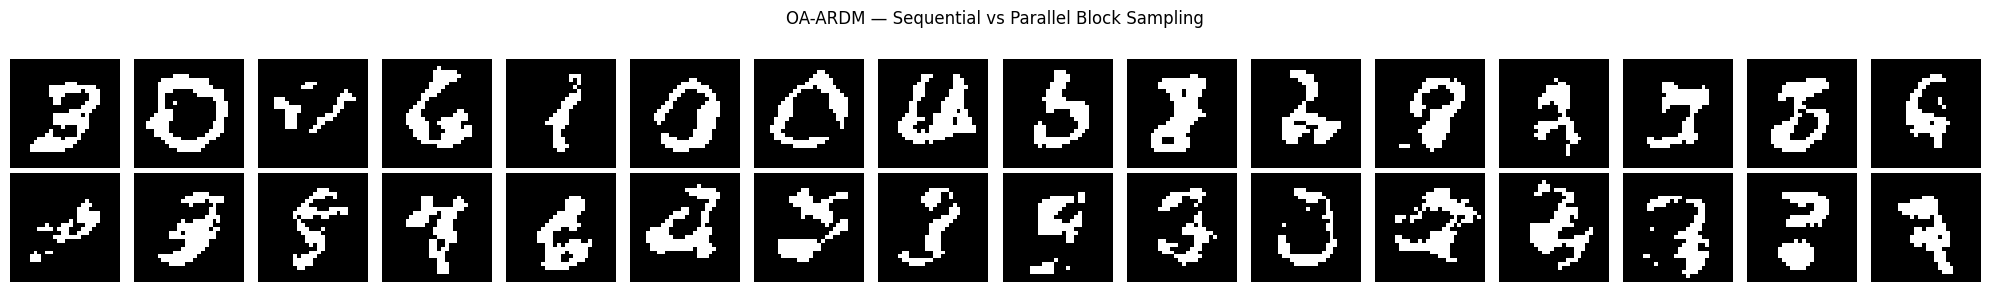

In [28]:
import time

# Sequential sampling
t0 = time.time()
samples_seq = sample_sequential(model, n_samples=16, device=device)
t_seq = time.time() - t0

# Parallel block sampling
t0 = time.time()
samples_par = sample_parallel(model, n_samples=16, block_size=50, device=device)
t_par = time.time() - t0

print(f"Sequential: {t_seq:.1f}s")
print(f"Parallel (block=50): {t_par:.1f}s")

# Plot side by side
fig, axes = plt.subplots(2, 16, figsize=(20, 3))

for i in range(16):
    axes[0, i].imshow(samples_seq[i].view(28, 28), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(samples_par[i].view(28, 28), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Sequential', fontsize=9)
axes[1, 0].set_ylabel('Parallel\n(block=50)', fontsize=9)
plt.suptitle('OA-ARDM — Sequential vs Parallel Block Sampling', fontsize=12)
plt.tight_layout()
plt.show()

Some of the generated samples are clearly recognisable digits, while others
have the right general shape but are hard to identify. Sequential sampling
produces slightly more coherent results, while parallel block sampling is
46x faster (0.5s vs 27.3s) at the cost of some visual quality.

# **5. Validation - Imputation on MNIST**

## 5.1 Imputation

One of the key properties of ARDM is that imputation comes for free. Since
the model is trained to predict any token given any subset of the others,
we can use it directly to reconstruct missing pixels without any changes
to the architecture or the training procedure. We simply fix the observed
pixels and sample the missing ones in a random order, conditioning on what
is already known at each step.

We test three observation rates to see how the model handles different
amounts of missing information:

- **90% visible:** almost all pixels are known, reconstruction should be easy
- **50% visible:** the interesting case, roughly half the image is missing
- **10% visible:** nearly blind reconstruction, very little context

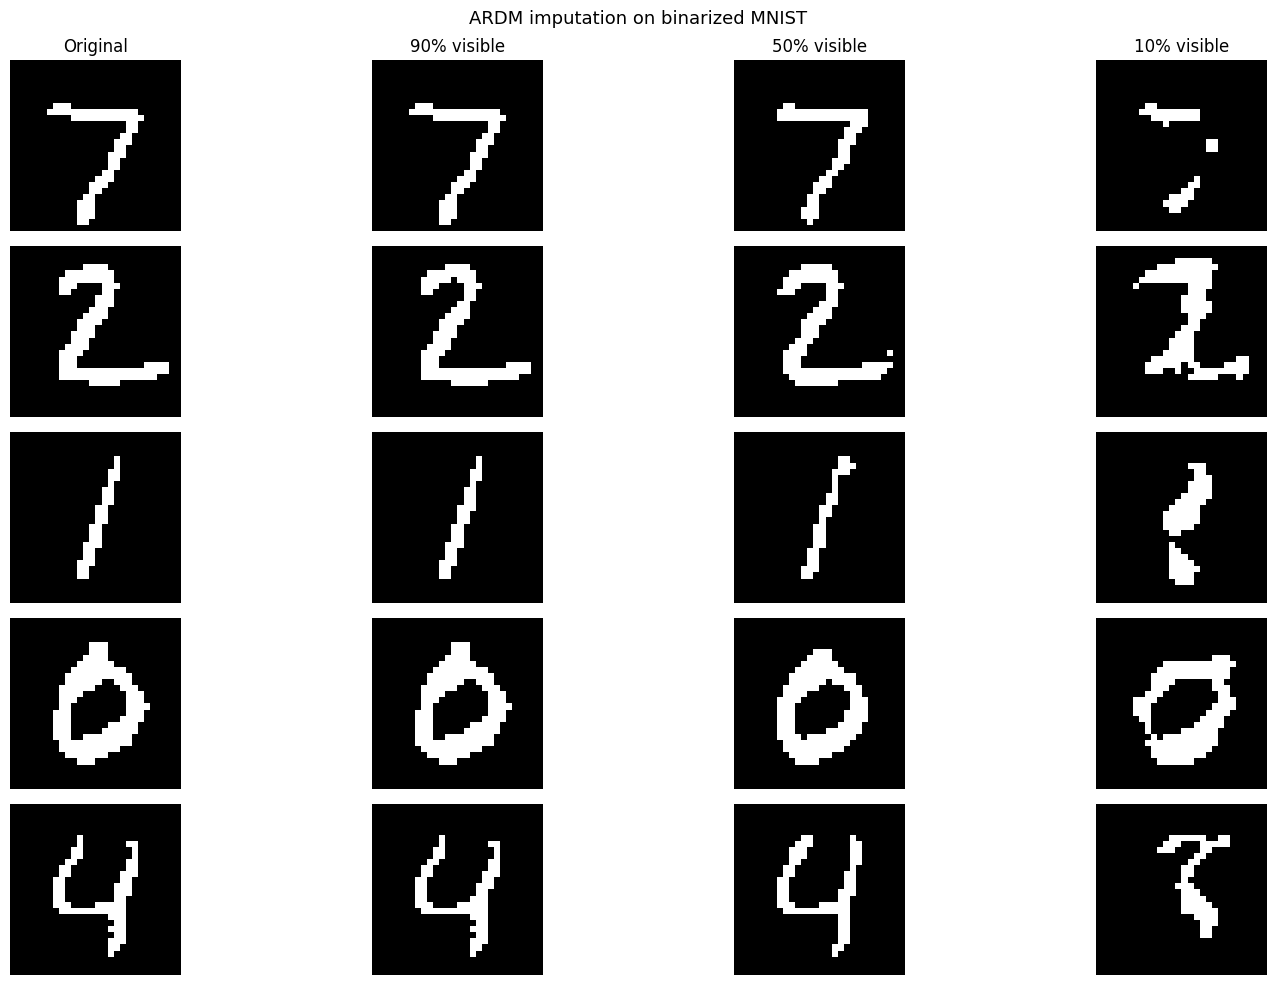

In [40]:
def impute(model, x, observed_mask, device):
    """
    x:             (784,) binary tensor — the full image
    observed_mask: (784,) bool tensor  — True = visible, False = missing
    """
    model.eval()
    masked_x = x.clone()
    masked_x[~observed_mask] = MASK  # hide the missing pixels

    # Sample missing pixels one by one in a random order.
    # The random order is key: it means the model conditions on a different
    # subset at each step, which is consistent with how it was trained.
    missing_positions = (~observed_mask).nonzero(as_tuple=True)[0]
    random_order      = missing_positions[torch.randperm(len(missing_positions))]

    with torch.no_grad():
        for pos in random_order:
            logits = model(masked_x.unsqueeze(0).to(device)).squeeze(-1)  # (1, 784)
            prob   = torch.sigmoid(logits[0, pos])
            masked_x[pos] = torch.bernoulli(prob)

    return masked_x


def show_imputation(model, testset, device, obs_rates=[0.9, 0.5, 0.1], n_images=5):
    images, _ = next(iter(testset))
    images    = images[:n_images].view(n_images, 784)

    fig, axes = plt.subplots(n_images, len(obs_rates) + 1,
                             figsize=(4 * (len(obs_rates) + 1), 2 * n_images))

    for i in range(n_images):
        x = images[i].long()

        # Original
        axes[i, 0].imshow(x.view(28, 28).cpu(), cmap='gray', vmin=0, vmax=1)
        axes[i, 0].axis('off')
        if i == 0:
            axes[i, 0].set_title("Original")

        for j, rate in enumerate(obs_rates):
            observed_mask = torch.rand(784) < rate
            result        = impute(model, x.clone(), observed_mask, device)

            axes[i, j+1].imshow(result.view(28, 28).cpu(), cmap='gray', vmin=0, vmax=1)
            axes[i, j+1].axis('off')
            if i == 0:
                axes[i, j+1].set_title(f"{int(rate*100)}% visible")

    plt.suptitle("ARDM imputation on binarized MNIST", fontsize=13)
    plt.tight_layout()
    plt.show()

show_imputation(model, testset, device)

At 90% visible the reconstructions are
nearly identical to the originals, and at 50% the digits are still clearly
recognisable and well-formed. At 10% visible the model struggles, which is
expected. When the model has a small amount of visible pixels, there is much more ambiguity
about which digit is being reconstructed. Some completions at 10% still
capture the right general shape (the 7 and the 0 are reasonable), while
others drift into a different but plausible digit shape.

This is exactly the expected behaviour for an ARDM model. It produces confident and accurate
reconstructions when enough context is available, and plausible but diverse
completions when the observation is very sparse.

## 5.1 Variability
Since ARDM is a generative model rather than a deterministic predictor,
running imputation multiple times on the same masked input produces
different completions each time. This reflects
the model's uncertainty about the missing pixels. Where the model is
confident, all completions look similar. Where it is uncertain,
the completions vary.

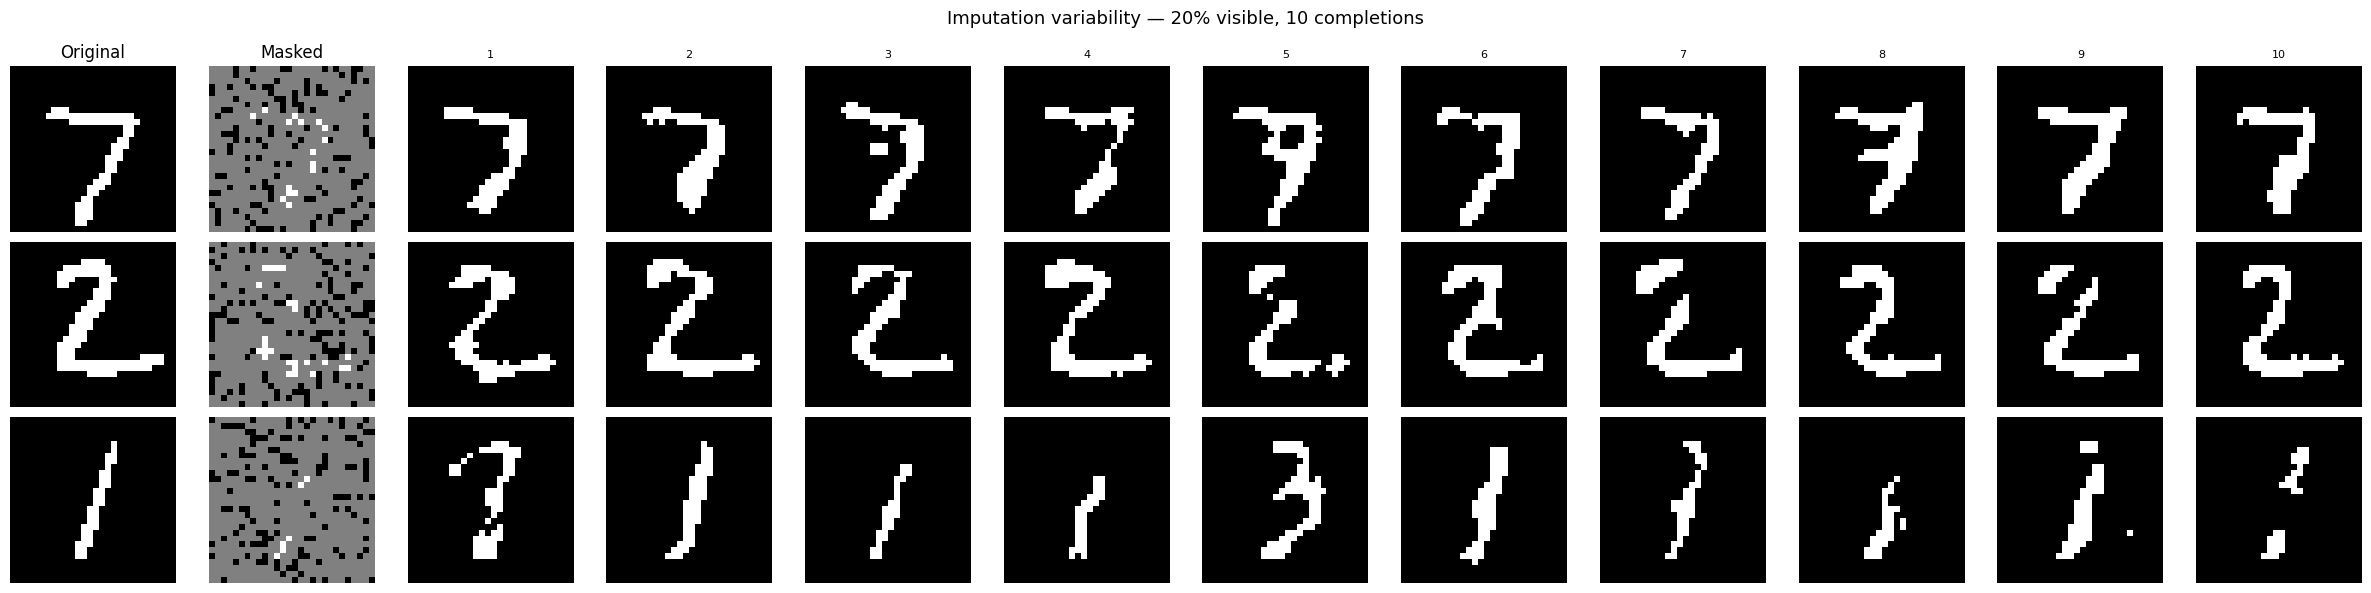

In [ ]:
def plot_imputation_variability(model, testset, device, n_samples=10, obs_rate=0.3):
    images, _ = next(iter(testset))
    n_images  = 3

    fig, axes = plt.subplots(n_images, 2 + n_samples,
                             figsize=(2 * (2 + n_samples), 2 * n_images))

    for i in range(n_images):
        x             = images[i].view(784).long()
        observed_mask = torch.rand(784) < obs_rate

        # Original
        axes[i, 0].imshow(x.view(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[i, 0].axis('off')
        if i == 0:
            axes[i, 0].set_title("Original")

        # Masked input — grey pixels are unknown
        masked_vis = x.clone().float()
        masked_vis[~observed_mask] = 0.5
        axes[i, 1].imshow(masked_vis.view(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[i, 1].axis('off')
        if i == 0:
            axes[i, 1].set_title("Masked")

        # Multiple completions from the same mask
        for j in range(n_samples):
            result = impute(model, x.clone(), observed_mask, device)
            axes[i, 2 + j].imshow(result.view(28, 28).cpu(), cmap='gray', vmin=0, vmax=1)
            axes[i, 2 + j].axis('off')
            if i == 0:
                axes[i, 2 + j].set_title(f"{j+1}", fontsize=8)

    plt.suptitle(f"Imputation variability — {int(obs_rate*100)}% visible, {n_samples} completions", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_imputation_variability(model, testset, device, n_samples=10, obs_rate=0.2)

The 7 and the 2 are consistently recognisable across all 10 completions
despite style differences. The 1 is more ambiguous as a few samples drift
towards other thin digits, which makes sense given how little context a
vertical stroke provides with only 20% of pixels visible.

## 5.3 Uncertainty

We can quantify the model's uncertainty by running imputation many times
and computing the pixel-wise entropy over the resulting completions. High
entropy at a position means the model is uncertain about that pixel.  Low entropy means the model
is confident, either because the pixel is observed or because the context
strongly constrains it.

For a binary pixel p, the entropy is:

$$H(p) = -p \log_2 p - (1-p) \log_2 (1-p)$$

where p is the fraction of completions that predicted pixel = 1.

/tmp/ipykernel_936/4064360763.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


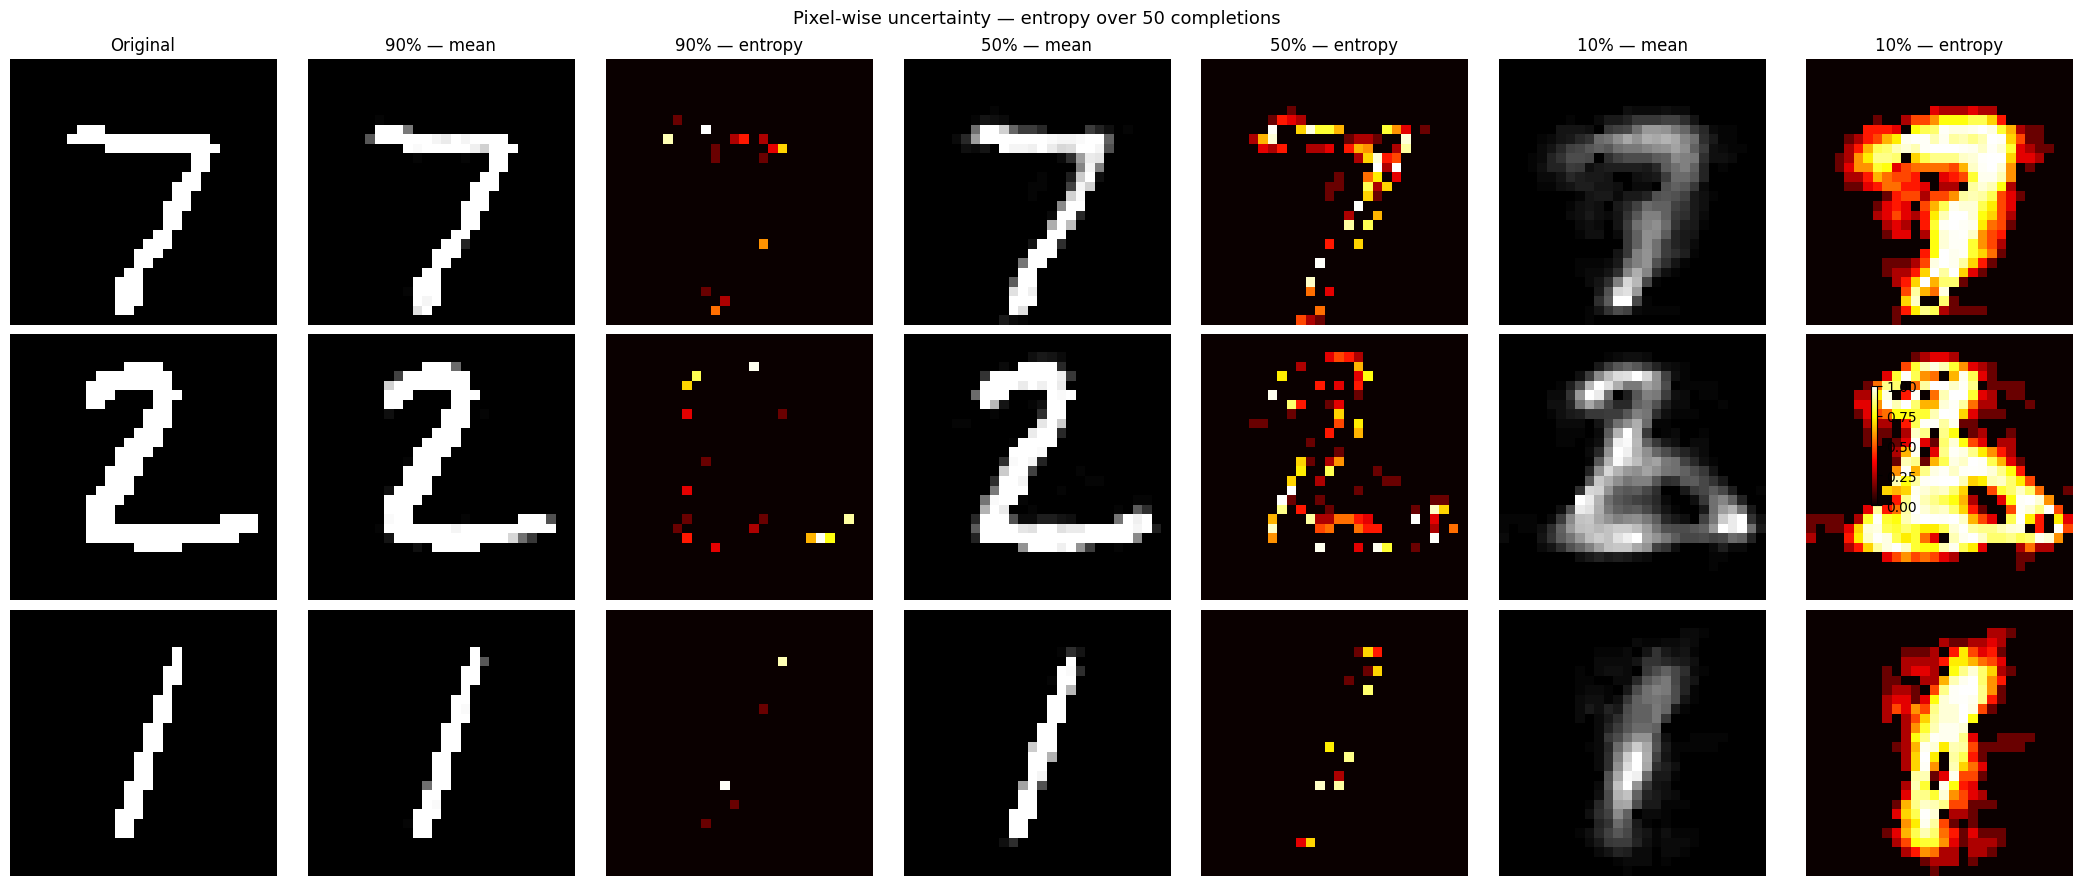


Mean entropy over missing pixels:
  90% visible → 0.0367 bits
  50% visible → 0.0745 bits
  10% visible → 0.2193 bits


In [ ]:
def imputation_entropy(model, x, observed_mask, device, n_samples=50):
    samples = []
    for _ in range(n_samples):
        result = impute(model, x.clone(), observed_mask, device)
        samples.append(result.float())

    samples = torch.stack(samples)   # (n_samples, 784)
    p       = samples.mean(dim=0)   # mean pixel value per position

    eps     = 1e-6
    entropy = -(p + eps) * torch.log2(p + eps) - (1 - p + eps) * torch.log2(1 - p + eps)
    entropy[observed_mask] = 0.0    # observed pixels have zero entropy

    return entropy, p


def plot_entropy(model, testset, device, obs_rates=[0.9, 0.5, 0.1], n_samples=50):
    images, _ = next(iter(testset))
    n_images  = 3

    fig, axes = plt.subplots(n_images, 1 + len(obs_rates) * 2,
                             figsize=(3 * (1 + len(obs_rates) * 2), 3 * n_images))

    for i in range(n_images):
        x = images[i].view(784).long()

        axes[i, 0].imshow(x.view(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[i, 0].axis('off')
        if i == 0:
            axes[i, 0].set_title("Original")

        for j, rate in enumerate(obs_rates):
            observed_mask   = torch.rand(784) < rate
            entropy, p      = imputation_entropy(model, x, observed_mask, device, n_samples)

            # Mean reconstruction
            axes[i, 1 + j*2].imshow(p.view(28, 28).cpu(), cmap='gray', vmin=0, vmax=1)
            axes[i, 1 + j*2].axis('off')
            if i == 0:
                axes[i, 1 + j*2].set_title(f"{int(rate*100)}% — mean")

            # Entropy map
            im = axes[i, 2 + j*2].imshow(entropy.view(28, 28).cpu(), cmap='hot', vmin=0, vmax=1)
            axes[i, 2 + j*2].axis('off')
            if i == 0:
                axes[i, 2 + j*2].set_title(f"{int(rate*100)}% — entropy")

    plt.colorbar(im, ax=axes[:, -1], fraction=0.03)
    plt.suptitle(f"Pixel-wise uncertainty — entropy over {n_samples} completions", fontsize=13)
    plt.tight_layout()
    plt.show()

    print("\nMean entropy over missing pixels:")
    for rate in obs_rates:
        observed_mask = torch.rand(784) < rate
        entropy, _    = imputation_entropy(model, images[0].view(784).long(),
                                           observed_mask, device, n_samples)
        print(f"  {int(rate*100)}% visible → {entropy[~observed_mask].mean():.4f} bits")

plot_entropy(model, testset, device)

The entropy maps show pixel-wise uncertainty over 50 completions. Bright
pixels (yellow/white) mean the model was uncertain and produced different values for that
position. Dark pixels mean the model
consistently predicted the same value. The mean image
shows the average pixel value across all 50 completions, which gives a
smoother version of the reconstruction.

At 90% visible the entropy maps are almost entirely dark, meaning the model
is highly confident about the missing pixels. The few bright spots correspond
to edge pixels where the exact stroke boundary is ambiguous. At 50% the
uncertainty spreads along the digit strokes showing that the model knows the general
shape but is less sure about the exact boundaries. At 10% the entropy is
high across the whole image, reflecting much more ambiguity about which digit
is being reconstructed.

The mean entropy numbers confirm this: 0.037 bits at 90% visible, rising
to 0.074 at 50% and 0.219 at 10%. The uncertainty scales naturally with
the amount of missing information.

# **6. Architecture comparison**

To better understand what the Transformer architecture is actually contributing,
we compare it against a simpler model: a small CNN. The CNN is simpler in two
important ways. It has fewer parameters, and its receptive field is local rather
than global. While the Transformer can attend to any pixel in the image regardless
of position, the CNN can only see a small neighbourhood around each pixel.

**Architecture:**
- Input encoding: token ids {0, 1, 2} → one-hot over 3 channels → reshaped to (3, 28, 28)
- Conv2d 3×3, 3 → 32 channels, padding=1 → ReLU
- Conv2d 3×3, 32 → 64 channels, padding=1 → ReLU
- Conv2d 3×3, 64 → 64 channels, padding=1 → ReLU
- Conv2d 1×1, 64 → 1 channel → one logit per position

Spatial resolution is preserved throughout (no pooling), so the output is
always (B, 784, 1). (same as Transformer)

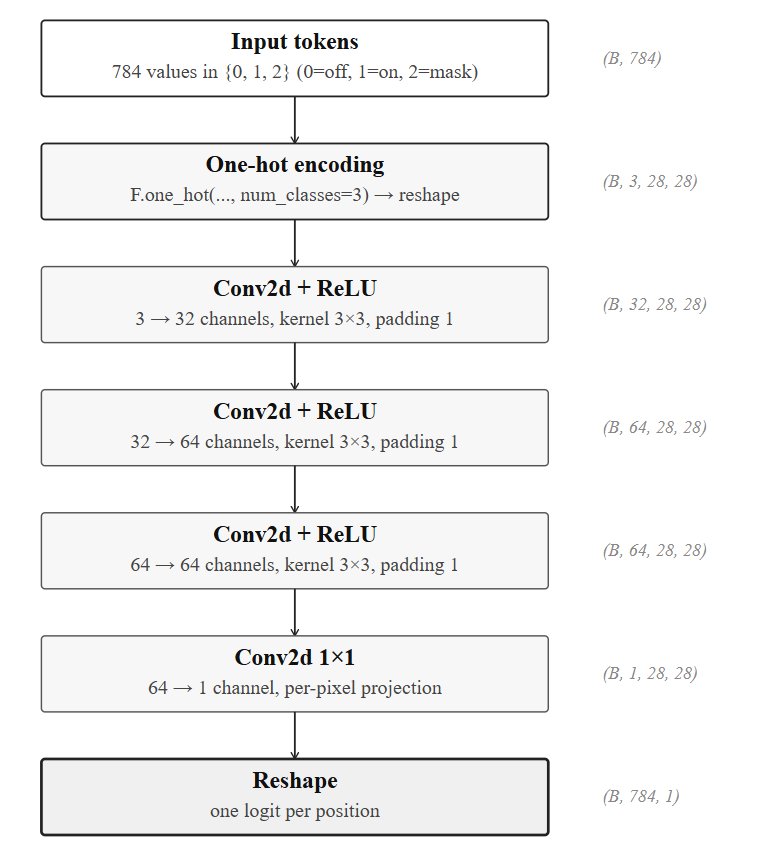

In [ ]:
from IPython.display import Image
Image(f"{SAVE_PATH}/cnn_architecture.png", width=350)

In [16]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # All convolutions use padding=1 to preserve spatial dimensions (28×28 throughout).
        # No pooling, we need one logit per pixel at the output.
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 3 input channels: pixel=0, pixel=1, MASK
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=1),  # 1×1 conv: one logit per position
        )

    def forward(self, x):
        # x: (B, 784) integer tokens in {0, 1, 2}
        # We encode each token as a one-hot vector over 3 channels,
        # then reshape to (B, 3, 28, 28) for the conv layers.
        B = x.shape[0]
        x_onehot = F.one_hot(x.long(), num_classes=3).float()        # (B, 784, 3)
        x_onehot = x_onehot.permute(0, 2, 1).reshape(B, 3, 28, 28)  # (B, 3, 28, 28)

        logits = self.encoder(x_onehot)   # (B, 1, 28, 28)
        return logits.reshape(B, 784, 1)  # (B, 784, 1)

cnn_model = SmallCNN().to(device)
print(f"Total parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

Total parameters: 56,385


**Training**


Since the CNN works on continuous values rather than token ids, we encode the
masked sequence as a one-hot tensor of shape (3, 28, 28), where the three channels
correspond to pixel off, pixel on, and MASK. Everything else follows the same
ARDM procedure: we sample a random permutation and step t, mask all positions
after t, and compute the loss at the target position only.

In [17]:
# Optimiser & scheduler
MASK = 2
cnn_epochs = 20
cnn_warmup = 5

cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=3e-4)
cnn_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    cnn_optimizer,
    T_max   = cnn_epochs - cnn_warmup,
    eta_min = 1e-5
)

CNN_SAVE_PATH = f"{SAVE_PATH}/cnn"
os.makedirs(CNN_SAVE_PATH, exist_ok=True)

# Training loop
cnn_train_losses = []
cnn_val_losses   = []

for epoch in range(cnn_epochs):

    # Train
    cnn_model.train()
    total_loss = 0

    for i, (images, _) in enumerate(trainset):
        B = images.shape[0]
        x = images.view(B, 784).long().to(device)

        sigma        = torch.argsort(torch.rand(B, 784), dim=1).to(device)
        t            = torch.randint(0, 784, (B,)).to(device)
        masked_x     = x.clone()
        t_expanded   = t.unsqueeze(1)
        positions    = torch.arange(784, device=device).unsqueeze(0)
        rank_mask    = positions >= t_expanded
        scatter_mask = torch.zeros(B, 784, dtype=torch.bool, device=device)
        scatter_mask.scatter_(1, sigma, rank_mask)
        masked_x[scatter_mask] = MASK

        target_pos = sigma[torch.arange(B, device=device), t]
        target_val = x[torch.arange(B, device=device), target_pos].float()

        logits = cnn_model(masked_x).squeeze(-1)
        pred   = logits[torch.arange(B, device=device), target_pos]
        loss   = F.binary_cross_entropy_with_logits(pred, target_val)

        cnn_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cnn_model.parameters(), 1.0)
        cnn_optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(trainset)
    cnn_train_losses.append(train_loss)

    # Validate
    cnn_model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for images, _ in valset:
            B = images.shape[0]
            x = images.view(B, 784).long().to(device)

            sigma        = torch.argsort(torch.rand(B, 784, device=device), dim=1)
            t            = torch.randint(0, 784, (B,), device=device)
            masked_x     = x.clone()
            t_expanded   = t.unsqueeze(1)
            positions    = torch.arange(784, device=device).unsqueeze(0)
            rank_mask    = positions >= t_expanded
            scatter_mask = torch.zeros(B, 784, dtype=torch.bool, device=device)
            scatter_mask.scatter_(1, sigma, rank_mask)
            masked_x[scatter_mask] = MASK

            target_pos = sigma[torch.arange(B, device=device), t]
            target_val = x[torch.arange(B, device=device), target_pos].float()

            logits = cnn_model(masked_x).squeeze(-1)
            pred   = logits[torch.arange(B, device=device), target_pos]
            loss   = F.binary_cross_entropy_with_logits(pred, target_val)
            total_val_loss += loss.item()

    val_loss = total_val_loss / len(valset)
    cnn_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{cnn_epochs} — train: {train_loss:.4f}, val: {val_loss:.4f}")

    # Save checkpoint every epoch
    torch.save(cnn_model.state_dict(), f"{CNN_SAVE_PATH}/cnn_epoch{epoch+1:02d}.pt")

    if epoch + 1 >= cnn_warmup:
        cnn_scheduler.step()

print("Training complete.")

Epoch 1/20 — train: 0.3524, val: 0.1884
Epoch 2/20 — train: 0.1572, val: 0.1543
Epoch 3/20 — train: 0.1413, val: 0.1375
Epoch 4/20 — train: 0.1366, val: 0.1320
Epoch 5/20 — train: 0.1282, val: 0.1362
Epoch 6/20 — train: 0.1266, val: 0.1258
Epoch 7/20 — train: 0.1248, val: 0.1192
Epoch 8/20 — train: 0.1235, val: 0.1252
Epoch 9/20 — train: 0.1216, val: 0.1251
Epoch 10/20 — train: 0.1212, val: 0.1349
Epoch 11/20 — train: 0.1208, val: 0.1198
Epoch 12/20 — train: 0.1215, val: 0.1143
Epoch 13/20 — train: 0.1206, val: 0.1137
Epoch 14/20 — train: 0.1187, val: 0.1164
Epoch 15/20 — train: 0.1183, val: 0.1181
Epoch 16/20 — train: 0.1189, val: 0.1158
Epoch 17/20 — train: 0.1190, val: 0.1187
Epoch 18/20 — train: 0.1181, val: 0.1128
Epoch 19/20 — train: 0.1208, val: 0.1139
Epoch 20/20 — train: 0.1203, val: 0.1123
Training complete.


We trained the SmallCNN for 20 epochs using Adam with lr=1e-4 and cosine
annealing. We found that the model converges quickly and both train and val
loss plateau around epoch 7-8.
The validation loss oscillates more than the Transformer under the stochastic
ARDM objective, so we used large validation batches (512) to reduce the
variance in the estimates. No early stopping was needed since the model
shows no signs of overfitting throughout training.

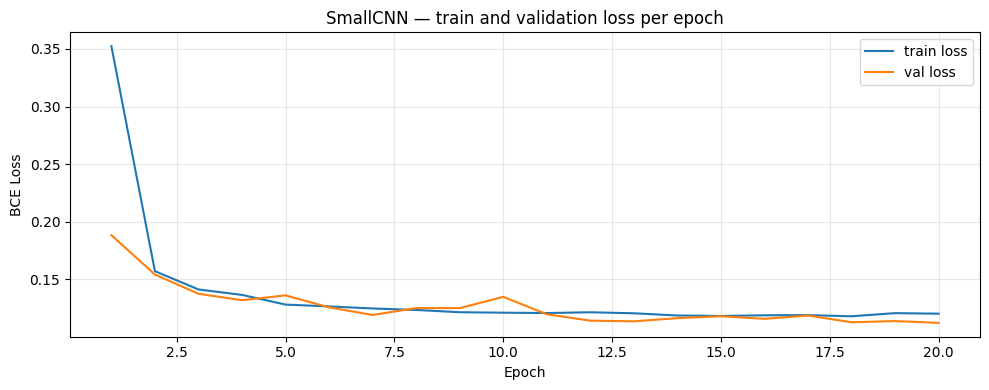

In [20]:
cnn_epoch_nums = list(range(1, len(cnn_train_losses) + 1))

plt.figure(figsize=(10, 4))
plt.plot(cnn_epoch_nums, cnn_train_losses,  label='train loss')
plt.plot(cnn_epoch_nums, cnn_val_losses,  label='val loss')
plt.title("SmallCNN — train and validation loss per epoch")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Load best model
torch.save(cnn_model.state_dict(), f"{CNN_SAVE_PATH}/cnn_final.pt")
print("Saved final CNN model.")

Saved final CNN model.


In [22]:
# Final test evaluation
cnn_model.eval()
total_test_loss = 0

with torch.no_grad():
    for images, _ in testset:
        B = images.shape[0]
        x = images.view(B, 784).long().to(device)

        sigma        = torch.argsort(torch.rand(B, 784, device=device), dim=1)
        t            = torch.randint(0, 784, (B,), device=device)
        masked_x     = x.clone()
        t_expanded   = t.unsqueeze(1)
        positions    = torch.arange(784, device=device).unsqueeze(0)
        rank_mask    = positions >= t_expanded
        scatter_mask = torch.zeros(B, 784, dtype=torch.bool, device=device)
        scatter_mask.scatter_(1, sigma, rank_mask)
        masked_x[scatter_mask] = MASK

        target_pos = sigma[torch.arange(B, device=device), t]
        target_val = x[torch.arange(B, device=device), target_pos].float()

        logits = cnn_model(masked_x).squeeze(-1)
        pred   = logits[torch.arange(B, device=device), target_pos]
        loss   = F.binary_cross_entropy_with_logits(pred, target_val)
        total_test_loss += loss.item()

cnn_test_loss = total_test_loss / len(testset)
print(f"Final test loss: {cnn_test_loss:.4f}")

Final test loss: 0.1130


**Evaluation**

CNN vs Transformer

In [24]:
WEIGHTS_PATH = f"{SAVE_PATH}/weights"

In [41]:
epoch_to_load = 15
cnn_model.load_state_dict(torch.load(
    f"{CNN_SAVE_PATH}/cnn_epoch{epoch_to_load:02d}.pt", map_location=device
))
cnn_model.eval()
print(f"Loaded CNN epoch {epoch_to_load}")

Loaded CNN epoch 15


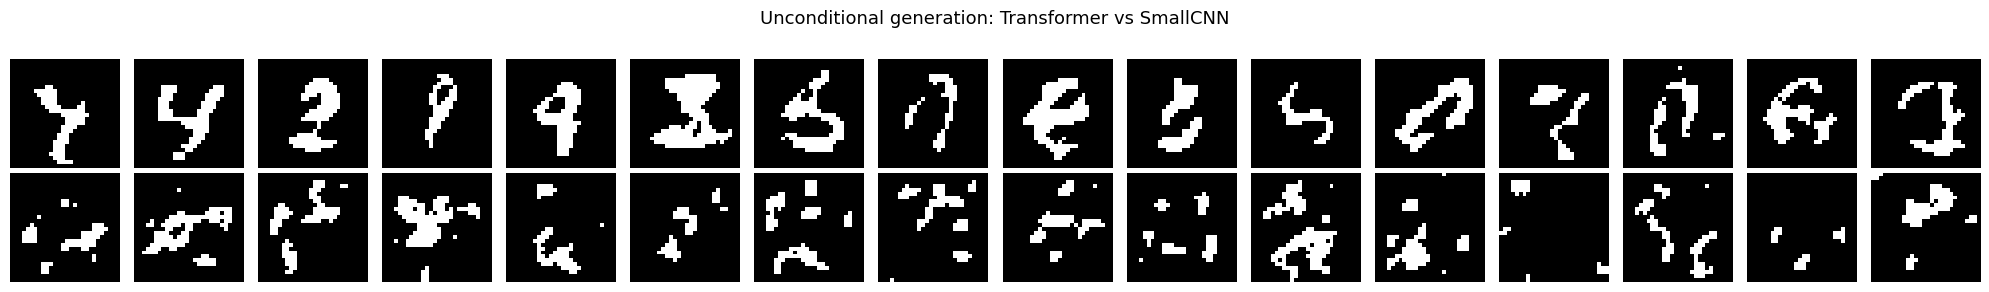

In [32]:
best_ckpt = torch.load(f"{WEIGHTS_PATH}/ardm_epoch45.pt", map_location=device)
if isinstance(best_ckpt, dict) and 'model_state_dict' in best_ckpt:
    model.load_state_dict(best_ckpt['model_state_dict'])
else:
    model.load_state_dict(best_ckpt)
model.eval()

# Generate samples from both models
transformer_samples = sample_sequential(model,     n_samples=16, device=device)
cnn_samples         = sample_sequential(cnn_model, n_samples=16, device=device)

fig, axes = plt.subplots(2, 16, figsize=(20, 3))

for i in range(16):
    axes[0, i].imshow(transformer_samples[i].view(28, 28), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(cnn_samples[i].view(28, 28),         cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Transformer', fontsize=9)
axes[1, 0].set_ylabel('SmallCNN',    fontsize=9)
plt.suptitle("Unconditional generation: Transformer vs SmallCNN", fontsize=13)
plt.tight_layout()
plt.show()

For unconditional generation, the Transformer produces digit-like shapes that are more recognisable. The CNN, however generates scattered, incoherent
pixel patterns.

This can be due to how each architecture handles sparse context. When generating from a fully
masked image, the first pixels are predicted with no neighbours revealed yet.
The Transformer can use any revealed pixel anywhere in the image regardless
of distance. The CNN can only see a small local window and if that window is
all MASK tokens, it has no useful information and guesses randomly.

The CNN could be improved with dilated convolutions, which increase the
receptive field of the model without adding parameters, allowing it to use
context from further away.

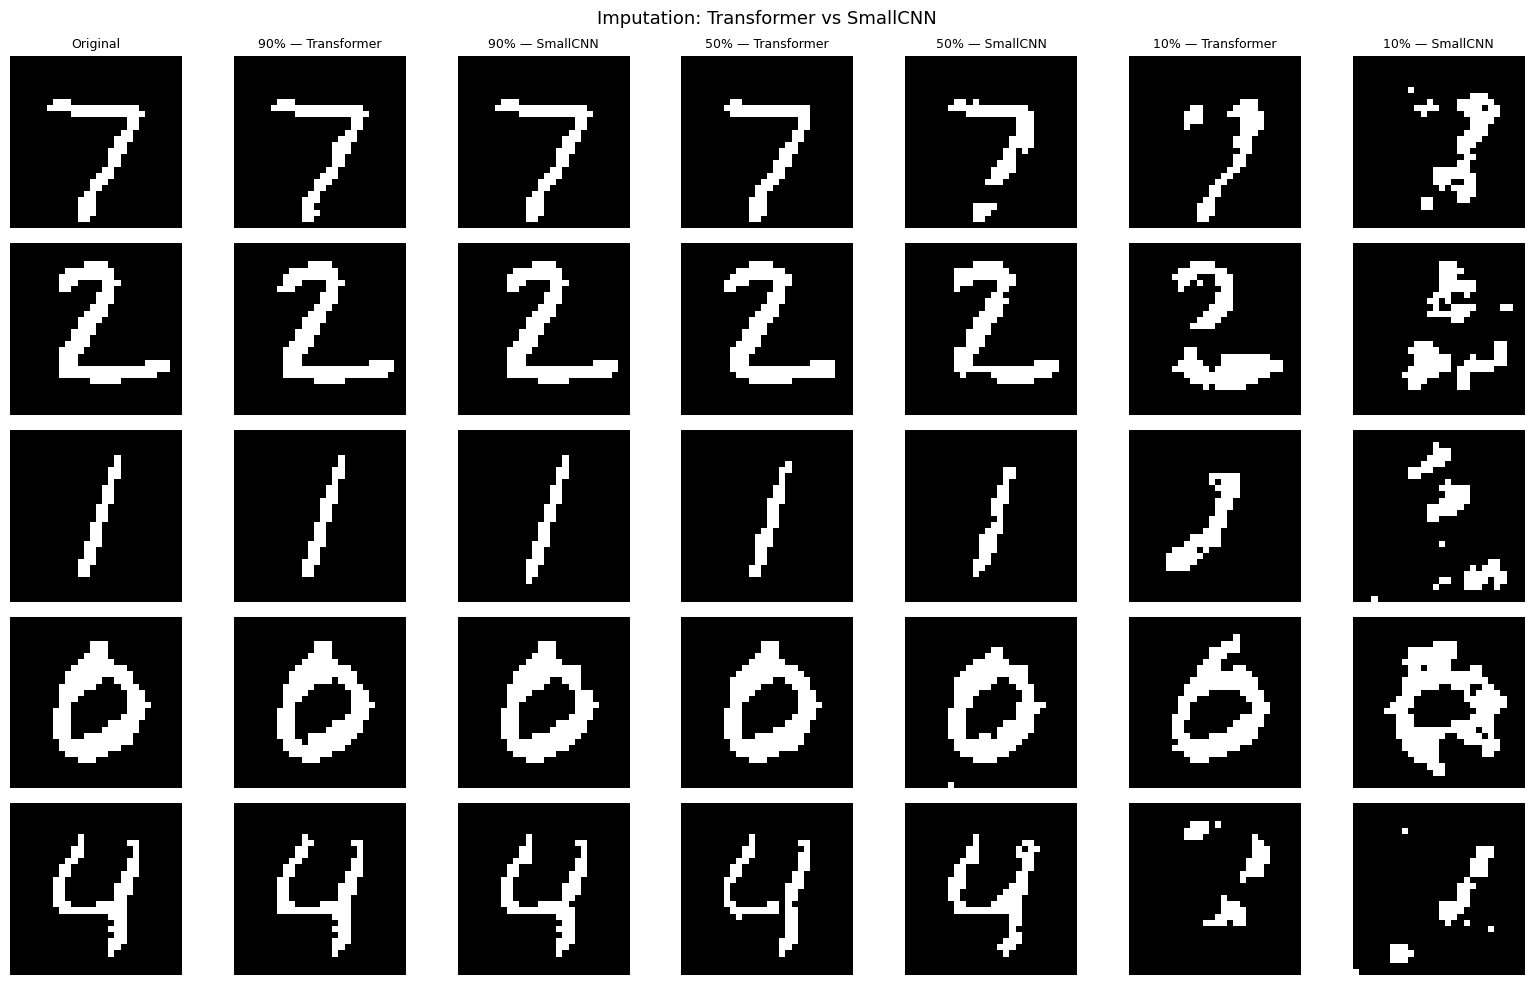

In [43]:
#  Imputation: Transformer vs SmallCNN
fig, axes = plt.subplots(5, 7, figsize=(16, 10))
images, _ = next(iter(testset))
obs_rates = [0.9, 0.5, 0.1]

for i in range(5):
    x = images[i].view(784).long()

    # Original
    axes[i, 0].imshow(x.view(28, 28), cmap='gray', vmin=0, vmax=1)
    axes[i, 0].axis('off')
    if i == 0: axes[i, 0].set_title("Original", fontsize=9)

    for j, rate in enumerate(obs_rates):
        observed_mask = torch.rand(784) < rate

        # Transformer
        result_t = impute(model,     x.clone(), observed_mask, device)
        axes[i, 1 + j*2].imshow(result_t.view(28, 28).cpu(), cmap='gray', vmin=0, vmax=1)
        axes[i, 1 + j*2].axis('off')
        if i == 0: axes[i, 1 + j*2].set_title(f"{int(rate*100)}% — Transformer", fontsize=9)

        # SmallCNN
        result_c = impute(cnn_model, x.clone(), observed_mask, device)
        axes[i, 2 + j*2].imshow(result_c.view(28, 28).cpu(), cmap='gray', vmin=0, vmax=1)
        axes[i, 2 + j*2].axis('off')
        if i == 0: axes[i, 2 + j*2].set_title(f"{int(rate*100)}% — SmallCNN", fontsize=9)

plt.suptitle("Imputation: Transformer vs SmallCNN", fontsize=13)
plt.tight_layout()
plt.show()

At 90% and 50% visible both models produce very similar results, despite
the CNN being far simpler and training much faster. The difference only
becomes clear at 10%, where the Transformer still produces recognisable
digits while the CNN breaks down into fragments. Global attention matters
when context is sparse, so when enough pixels are visible, local convolutions
are much simpler and work equally well.

# **7. Tabular Data — ARDM on UCI Mushroom**

To test whether the ARDM framework generalises beyond images, we apply it to the
UCI Mushroom dataset. This dataset contains 8,124 mushroom samples described by
22 categorical features such as cap shape, odour, and gill colour. Each feature
takes a small number of discrete values, making it a natural fit for the ARDM
framework: we can treat each feature as a token and train the model to predict
any missing feature given the observed ones.

We build a global vocabulary by mapping every unique feature value across all
columns to a single integer id, with one additional token reserved for MASK.

In [ ]:
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from torch.utils.data import TensorDataset, DataLoader

# ── Load data ──────────────────────────────────────────────────────────────────
mushroom = fetch_openml(name='mushroom', version=1, as_frame=True, parser='auto')
features = mushroom.data.dropna()
print(f"Dataset shape: {features.shape}")
print(f"Features: {list(features.columns)}")

# ── Build global vocabulary ────────────────────────────────────────────────────
# Map every unique value across all columns to a single integer id.
# Values are sorted for reproducibility. MASK gets the next id after all feature values.
all_values  = sorted(set(v for col in features.columns for v in features[col].unique()))
value_to_id = {v: i for i, v in enumerate(all_values)}
id_to_value = {v: k for k, v in value_to_id.items()}

VOCAB_SIZE  = len(all_values)
MASK_TOKEN  = VOCAB_SIZE        # MASK id = VOCAB_SIZE
SEQ_LEN     = features.shape[1] # 22 features

print(f"\nVocabulary size: {VOCAB_SIZE}")
print(f"MASK token id:   {MASK_TOKEN}")
print(f"Sequence length: {SEQ_LEN}")

# Encode and split
# 60% train / 20% validation / 20% test
# Validation is used for early stopping; test is held out for final evaluation only.
encoded = features.map(lambda x: value_to_id[x]).values
data    = torch.tensor(encoded, dtype=torch.long)

n_train = int(0.60 * len(data))
n_val   = int(0.20 * len(data))

train_data = data[:n_train]
val_data   = data[n_train:n_train + n_val]
test_data  = data[n_train + n_val:]

tab_trainset = DataLoader(TensorDataset(train_data), batch_size=64, shuffle=True)
tab_valset   = DataLoader(TensorDataset(val_data),   batch_size=64, shuffle=False)
tab_testset  = DataLoader(TensorDataset(test_data),  batch_size=64, shuffle=False)

print(f"\nTrain samples:      {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples:       {len(test_data)}")

Dataset shape: (5644, 22)
Features: ['cap-shape', 'cap-surface', 'cap-color', 'bruises%3F', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Vocabulary size: 22
MASK token id:   22
Sequence length: 22

Train samples:      3386
Validation samples: 1128
Test samples:       1130


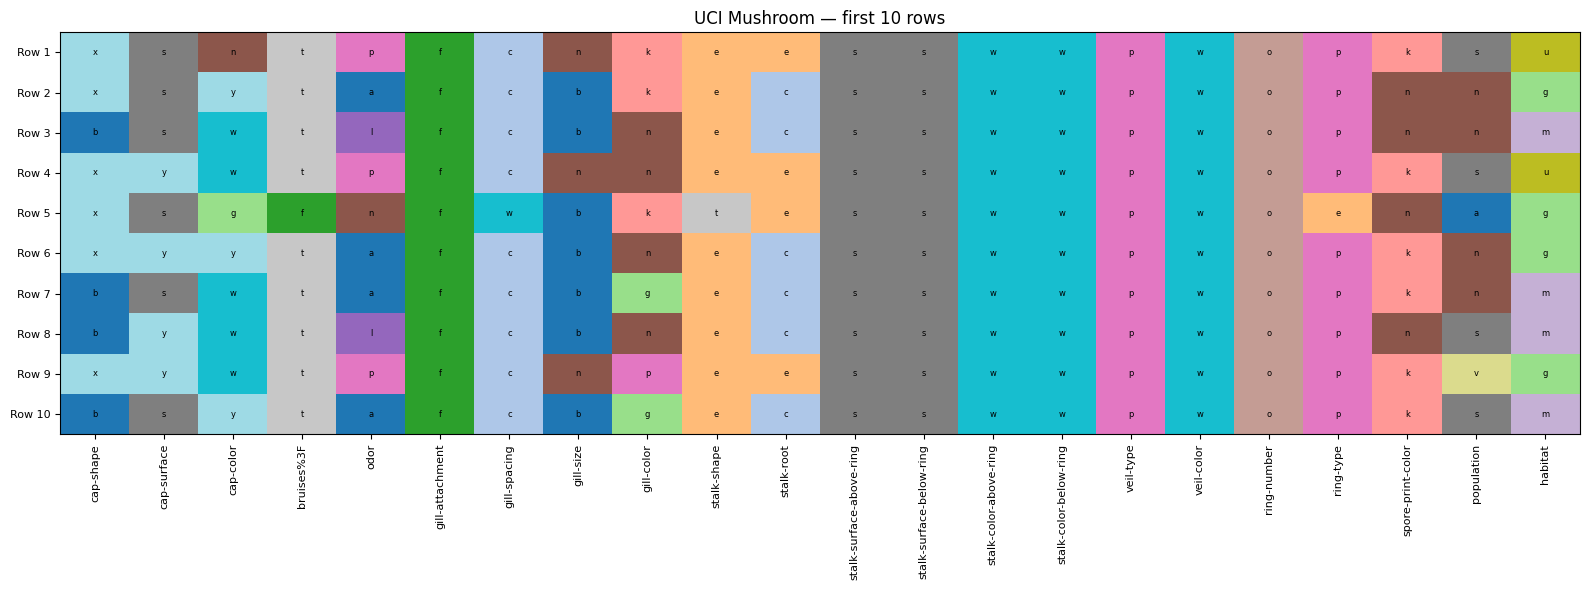

In [ ]:
def visualize_tabular_data(data, n_rows=10):
    id_to_value = {v: k for k, v in value_to_id.items()}

    # Convert a few rows back to readable labels
    labels = [[id_to_value[v.item()] for v in row] for row in data[:n_rows]]

    fig, ax = plt.subplots(figsize=(16, n_rows * 0.6))
    ax.imshow([[v.item() for v in row] for row in data[:n_rows]],
              aspect='auto', cmap='tab20')

    # Annotate with actual values
    for i in range(n_rows):
        for j in range(SEQ_LEN):
            ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=6)

    ax.set_xticks(range(SEQ_LEN))
    ax.set_xticklabels(features.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([f"Row {i+1}" for i in range(n_rows)], fontsize=8)
    ax.set_title("UCI Mushroom — first 10 rows", fontsize=12)
    plt.tight_layout()
    plt.show()

visualize_tabular_data(train_data)

We made the following changes to adapt the Transformer to the tabular setting:

- **Sequence length**: 22 (one position per feature) instead of 784
- **Vocabulary**: all unique feature values across all columns plus a MASK token, instead of just 0, 1, MASK
- **Output head**: one logit per vocabulary value instead of a single binary logit
- **Loss**: cross-entropy instead of binary cross-entropy

Several additional changes were found through experimentation. We initially used
the same model size as the image case, but the dataset is small enough (8k samples)
that the model overfit quickly. We progressively reduced the model capacity
and added regularisation until the training and validation curves converged
reasonably:

- **Embedding dimension**: 64 instead of 128
- **Hidden size**: 128 instead of 256
- **Layers**: 3 instead of 4
- **Attention heads**: 4 (unchanged)
- **Dropout**: 0.4 instead of 0.0

In [ ]:
tab_model = TransformerNet(
    num_src_vocab = VOCAB_SIZE + 1,
    num_tgt_vocab = VOCAB_SIZE,
    embedding_dim = 64,
    hidden_size   = 128,
    nheads        = 4,
    n_layers      = 3,
    max_src_len   = SEQ_LEN,
    max_tgt_len   = SEQ_LEN,
    dropout       = 0.4
).to(device)


**Training**

The random baseline for this task is ln(23) ≈ 3.13, since we use a global
vocabulary of 23 unique values and a random predictor would guess uniformly
over all of them. A more informative baseline is the per-feature average,
ln(5.5) ≈ 1.70, since most features only have 5 or 6 valid values.

We started with the same training setup as the image case (Adam, lr=3e-4,
cosine annealing over 50 epochs) but found the model was oscillating and
overfitting. We experimented with several adjustments:

- Lowering the learning rate to 1e-4 stabilised training but slowed
  convergence significantly
- Reducing T_max in the cosine scheduler helped the model converge faster
- Using a smaller batch size for both training and validation smoothed
  the curves and reduced the train/val gap
- Adding early stopping with patience 10 prevented the model from
  continuing to overfit after the validation loss stopped improving

We also added a proper 60/20/20 train/val/test split so that the test
set is never used for any training decisions and gives a clean final
evaluation.

In [ ]:
# Optimiser & scheduler
tab_epochs = 100   # upper bound — early stopping will cut it short
tab_warmup = 10
patience   = 10    # stop if val loss does not improve for 10 consecutive epochs

tab_optimizer = torch.optim.Adam(tab_model.parameters(), lr=1e-4, weight_decay=1e-4)
tab_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    tab_optimizer,
    T_max   = tab_epochs - tab_warmup,
    eta_min = 1e-5
)

TAB_SAVE_PATH = f"{SAVE_PATH}/tabular"
os.makedirs(TAB_SAVE_PATH, exist_ok=True)

#  Training loop
tab_train_losses = []
tab_val_losses   = []

best_val_loss     = float('inf')
best_epoch        = 0
epochs_no_improve = 0

def ardm_loss(model, x, seq_len, mask_token, device, loss_fn):
    B = x.shape[0]
    x = x.to(device)

    sigma        = torch.argsort(torch.rand(B, seq_len), dim=1).to(device)
    t            = torch.randint(0, seq_len, (B,)).to(device)
    masked_x     = x.clone()
    t_expanded   = t.unsqueeze(1)
    positions    = torch.arange(seq_len, device=device).unsqueeze(0)
    rank_mask    = positions >= t_expanded
    scatter_mask = torch.zeros(B, seq_len, dtype=torch.bool, device=device)
    scatter_mask.scatter_(1, sigma, rank_mask)
    masked_x[scatter_mask] = mask_token

    target_pos = sigma[torch.arange(B, device=device), t]
    target_val = x[torch.arange(B, device=device), target_pos]

    logits = model(masked_x)
    pred   = logits[torch.arange(B, device=device), target_pos]
    return loss_fn(pred, target_val)


for epoch in range(tab_epochs):

    #  Train
    tab_model.train()
    total_loss = 0
    for (x,) in tab_trainset:
        loss = ardm_loss(tab_model, x, SEQ_LEN, MASK_TOKEN, device, F.cross_entropy)
        tab_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tab_model.parameters(), 1.0)
        tab_optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / len(tab_trainset)
    tab_train_losses.append(train_loss)

    #  Validate
    tab_model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for (x,) in tab_valset:
            loss = ardm_loss(tab_model, x, SEQ_LEN, MASK_TOKEN, device, F.cross_entropy)
            total_val_loss += loss.item()

    val_loss = total_val_loss / len(tab_valset)
    tab_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{tab_epochs} — train: {train_loss:.4f}, val: {val_loss:.4f}")

    #  Save best model and check early stopping
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_epoch        = epoch + 1
        epochs_no_improve = 0
        torch.save(tab_model.state_dict(), f"{TAB_SAVE_PATH}/tab_best.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} — best epoch: {best_epoch}, val loss: {best_val_loss:.4f}")
        break

    if epoch + 1 >= tab_warmup:
        tab_scheduler.step()

# Load best model
tab_model.load_state_dict(torch.load(f"{TAB_SAVE_PATH}/tab_best.pt", map_location=device))
print(f"\nLoaded best model from epoch {best_epoch} — val loss: {best_val_loss:.4f}")

Epoch 1/100 — train: 2.9048, val: 2.7434
Epoch 2/100 — train: 2.4839, val: 2.5055
Epoch 3/100 — train: 2.1567, val: 2.2480
Epoch 4/100 — train: 1.8682, val: 2.1258
Epoch 5/100 — train: 1.6794, val: 1.9485
Epoch 6/100 — train: 1.5654, val: 1.9345
Epoch 7/100 — train: 1.4643, val: 1.8095
Epoch 8/100 — train: 1.4151, val: 1.7634
Epoch 9/100 — train: 1.3189, val: 1.6902
Epoch 10/100 — train: 1.2400, val: 1.7260
Epoch 11/100 — train: 1.1740, val: 1.6635
Epoch 12/100 — train: 1.1346, val: 1.6407
Epoch 13/100 — train: 1.0928, val: 1.5297
Epoch 14/100 — train: 1.0665, val: 1.5905
Epoch 15/100 — train: 1.0136, val: 1.5377
Epoch 16/100 — train: 0.9892, val: 1.4354
Epoch 17/100 — train: 0.9430, val: 1.4779
Epoch 18/100 — train: 0.9483, val: 1.4643
Epoch 19/100 — train: 0.8956, val: 1.3217
Epoch 20/100 — train: 0.8664, val: 1.4203
Epoch 21/100 — train: 0.8642, val: 1.3630
Epoch 22/100 — train: 0.8292, val: 1.3383
Epoch 23/100 — train: 0.8117, val: 1.3186
Epoch 24/100 — train: 0.8193, val: 1.3326
E

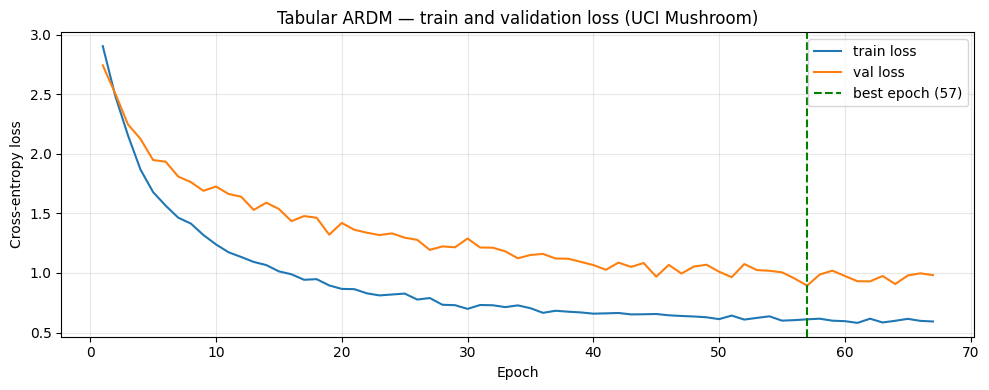

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(tab_train_losses) + 1), tab_train_losses, label='train loss')
plt.plot(range(1, len(tab_val_losses)   + 1), tab_val_losses, label='val loss')
plt.axvline(x=best_epoch, color='green', linestyle='--', label=f'best epoch ({best_epoch})')
plt.title("Tabular ARDM — train and validation loss (UCI Mushroom)")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Evaluation**

In [ ]:
# Evaluate on the test set using the best model
tab_model.eval()
total_test_loss = 0

with torch.no_grad():
    for (x,) in tab_testset:
        loss = ardm_loss(tab_model, x, SEQ_LEN, MASK_TOKEN, device, F.cross_entropy)
        total_test_loss += loss.item()

test_loss = total_test_loss / len(tab_testset)
print(f"Final test loss: {test_loss:.4f}")

Final test loss: 1.5592


Both curves decrease steadily from around 3.0 down to 0.6 and 0.95,
which is a meaningful improvement over the random baseline of 3.13.
The validation curve is noisier than the training curve, which we expected
given the small dataset size and the stochastic nature of the ARDM objective.
The gap between the two is stable and not growing, so the model is learning
but generalisation is limited by the 8k sample size.

The final test loss is 1.56, which is higher than the validation loss of
0.95. The gap is larger than we would like, but with only 8k samples split
three ways the test set is small enough that this kind of variance is normal.
The loss is still well below the random baseline of 3.13, so the model is
picking up real structure in the data.

**Evaluation**

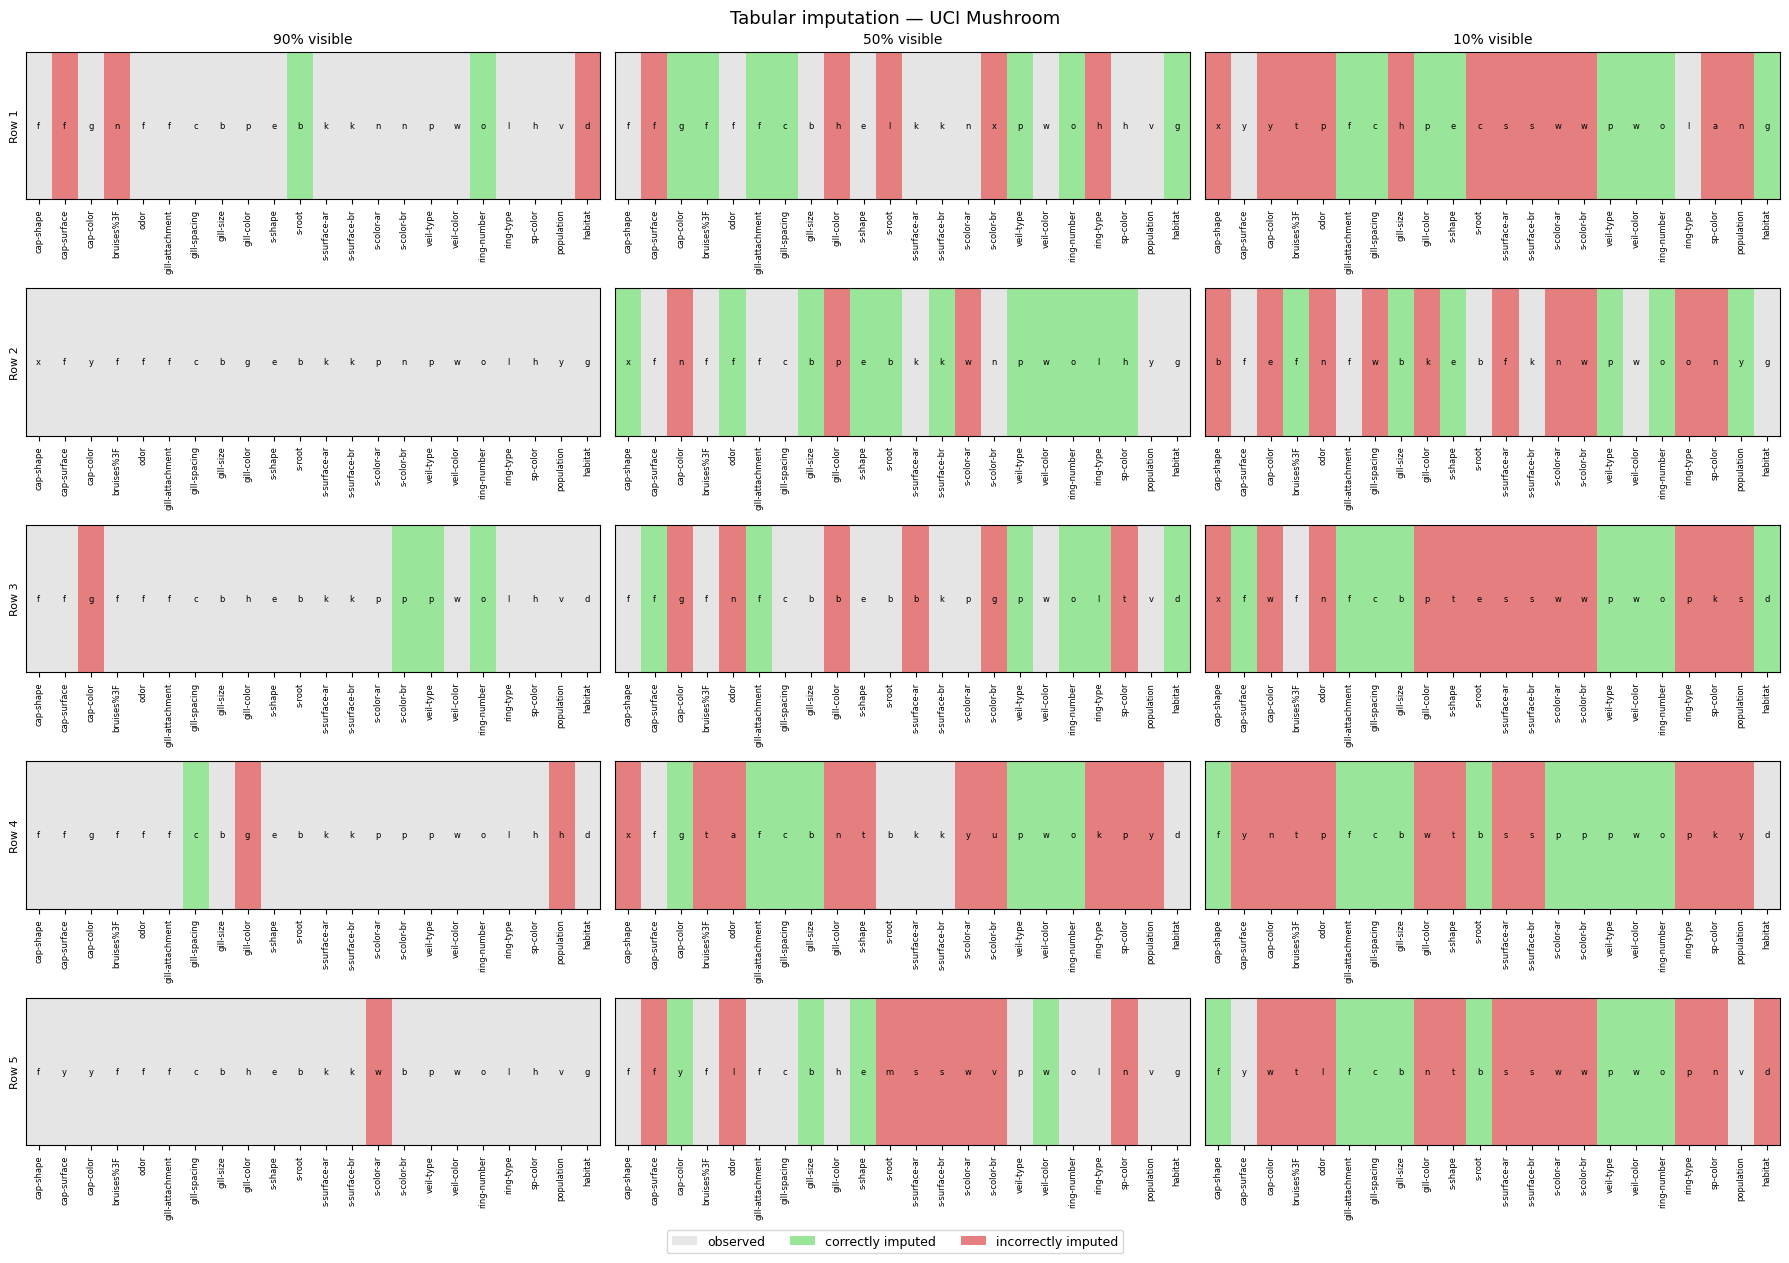

In [ ]:
def visualize_imputation_tabular(model, data, device, obs_rates=[0.9, 0.5, 0.1], n_rows=5):
    model.eval()
    id_to_value = {v: k for k, v in value_to_id.items()}

    fig, axes = plt.subplots(n_rows, len(obs_rates), figsize=(18, n_rows * 2.5))
    fig.suptitle("Tabular imputation — UCI Mushroom", fontsize=13)

    for i in range(n_rows):
        x = data[i].clone()

        for k, rate in enumerate(obs_rates):
            observed_mask = torch.rand(SEQ_LEN) < rate
            result = impute_tabular(model, x.clone(), observed_mask, device)

            colors = []
            labels = []
            for j in range(SEQ_LEN):
                original = id_to_value[x[j].item()]
                imputed  = id_to_value[result[j].item()]

                if observed_mask[j]:
                    colors.append([0.9, 0.9, 0.9])   # grey — observed
                    labels.append(original)
                elif imputed == original:
                    colors.append([0.6, 0.9, 0.6])   # green — correctly imputed
                    labels.append(imputed)
                else:
                    colors.append([0.9, 0.5, 0.5])   # red — incorrectly imputed
                    labels.append(imputed)

            ax = axes[i, k]
            ax.imshow([colors], aspect='auto')
            ax.set_xticks(range(SEQ_LEN))
            ax.set_xticklabels(
                [c.replace('stalk-', 's-').replace('spore-print-', 'sp-')
                   .replace('-above-ring', '-ar').replace('-below-ring', '-br')
                 for c in features.columns],
                rotation=90, fontsize=6
            )
            ax.set_yticks([])

            for j, label in enumerate(labels):
                ax.text(j, 0, label, ha='center', va='center', fontsize=6)

            if i == 0:
                ax.set_title(f"{int(rate*100)}% visible", fontsize=10)
            if k == 0:
                ax.set_ylabel(f"Row {i+1}", fontsize=8)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=[0.9, 0.9, 0.9], label='observed'),
        Patch(facecolor=[0.6, 0.9, 0.6], label='correctly imputed'),
        Patch(facecolor=[0.9, 0.5, 0.5], label='incorrectly imputed'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
               fontsize=9, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()

visualize_imputation_tabular(tab_model, test_data, device)

In [ ]:
#  Imputation accuracy
# For each observation rate, compute the fraction of correctly imputed features
def imputation_accuracy(model, testset, device, obs_rate, n_samples=200):
    model.eval()
    correct = 0
    total   = 0

    (x_batch,) = next(iter(testset))
    x_batch = x_batch[:n_samples].to(device)

    for i in range(len(x_batch)):
        x = x_batch[i]
        observed_mask = torch.rand(SEQ_LEN) < obs_rate
        result = impute_tabular(model, x.clone(), observed_mask, device)

        # Count correct predictions on missing positions only
        missing = ~observed_mask
        correct += (result[missing] == x[missing]).sum().item()
        total += missing.sum().item()

    return correct / total if total > 0 else 0.0


print("Imputation accuracy on missing features:")
for rate in [0.9, 0.5, 0.1]:
    acc = imputation_accuracy(tab_model, tab_testset, device, obs_rate=rate)
    print(f"  {int(rate*100)}% visible → {acc:.3f}")

Imputation accuracy on missing features:
  90% visible → 0.562
  50% visible → 0.486
  10% visible → 0.403


Although they are not very high, the imputation accuracy values are well above random (1/23 ≈ 0.04), which confirms the
model has learned some meaningful correlations between features. The accuracy
drops as fewer features are observed, which is expected, but the drop is
relatively small, even with only 10% of features visible the model still
gets almost half of the missing ones right.


The results are harder to interpret than in the image case. The
train/val gap was difficult to close and the test loss is higher than the
validation loss, which makes it hard to draw strong conclusions about how
well the model actually generalises. This could be due to the small dataset
size, the global vocabulary design, or both.

To properly evaluate whether
ARDM with a Transformer is a good fit for tabular data, we would need to
run more controlled experiments, for example comparing global vs
per-feature vocabulary, or trying a larger dataset.